# 02 · Predictive maintenance — FD001

This notebook grows block by block during Phase 1.
- **Block 1.2** (sections 1–5): features and leakage-safe validation.
- **Block 1.3** (sections 6–11): model comparison, decision threshold and test evaluation.
- **Block 1.4** (sections 12–18): unsupervised anomaly detection and lead time.

Decisions taken from notebook 01 (details in `docs/ml.md`):
- 14 sensors kept; the 6 constant sensors, the near-constant sensor 6 and the 3 operational settings are discarded.
- Sensor noise is large compared with the degradation trend until roughly the last 50–100 cycles, so the level of each sensor is smoothed.
- Units start at different levels, so each unit is compared with its own early-life baseline.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score

from industrial_ai.ml.data import SENSOR_DESCRIPTIONS, load_trajectories
from industrial_ai.ml.features import FeatureConfig, build_features
from industrial_ai.ml.labels import LABEL_COLUMN, add_failure_label, add_rul_train
from industrial_ai.ml.split import unit_group_kfold

HORIZON = 30
config = FeatureConfig()

train = add_failure_label(add_rul_train(load_trajectories("FD001", "train")), HORIZON)
features = build_features(train, config)
print(f"{features.shape[1]} features for {len(features):,} rows")
features.head()

42 features for 20,631 rows


,sensor_2_mean10,sensor_2_trend10,sensor_2_delta_baseline,sensor_3_mean10,sensor_3_trend10,sensor_3_delta_baseline,sensor_4_mean10,sensor_4_trend10,sensor_4_delta_baseline,sensor_7_mean10,...,sensor_15_delta_baseline,sensor_17_mean10,sensor_17_trend10,sensor_17_delta_baseline,sensor_20_mean10,sensor_20_trend10,sensor_20_delta_baseline,sensor_21_mean10,sensor_21_trend10,sensor_21_delta_baseline
0,641.820000,0.0,0.0,1589.700000,0.0,0.0,1400.600000,0.0,0.0,554.360000,...,0.0,392.000000,0.0,0.0,39.060000,0.0,0.0,23.419000,0.0,0.0
1,641.985000,0.0,0.0,1590.760000,0.0,0.0,1401.870000,0.0,0.0,554.055000,...,0.0,392.000000,0.0,0.0,39.030000,0.0,0.0,23.421300,0.0,0.0
2,642.106667,0.0,0.0,1589.836667,0.0,0.0,1402.646667,0.0,0.0,554.123333,...,0.0,391.333333,0.0,0.0,39.003333,0.0,0.0,23.395600,0.0,0.0
3,642.167500,0.0,0.0,1588.075000,0.0,0.0,1402.452500,0.0,0.0,554.205000,...,0.0,391.500000,0.0,0.0,38.972500,0.0,0.0,23.390175,0.0,0.0
4,642.208000,0.0,0.0,1587.030000,0.0,0.0,1403.206000,0.0,0.0,554.164000,...,0.0,391.800000,0.0,0.0,38.958000,0.0,0.0,23.393020,0.0,0.0


## 1. What the three features look like

For one unit and one sensor:
- **rolling mean:** the denoised level of the sensor;
- **delta_baseline:** how far that level has moved from the unit's own first cycles, removing the unit-to-unit offset seen in notebook 01;
- **trend:** how much the level changed over the last `trend_lag` cycles, which should grow as degradation accelerates.

The dashed line marks the start of the positive label (the last `HORIZON` cycles before failure).

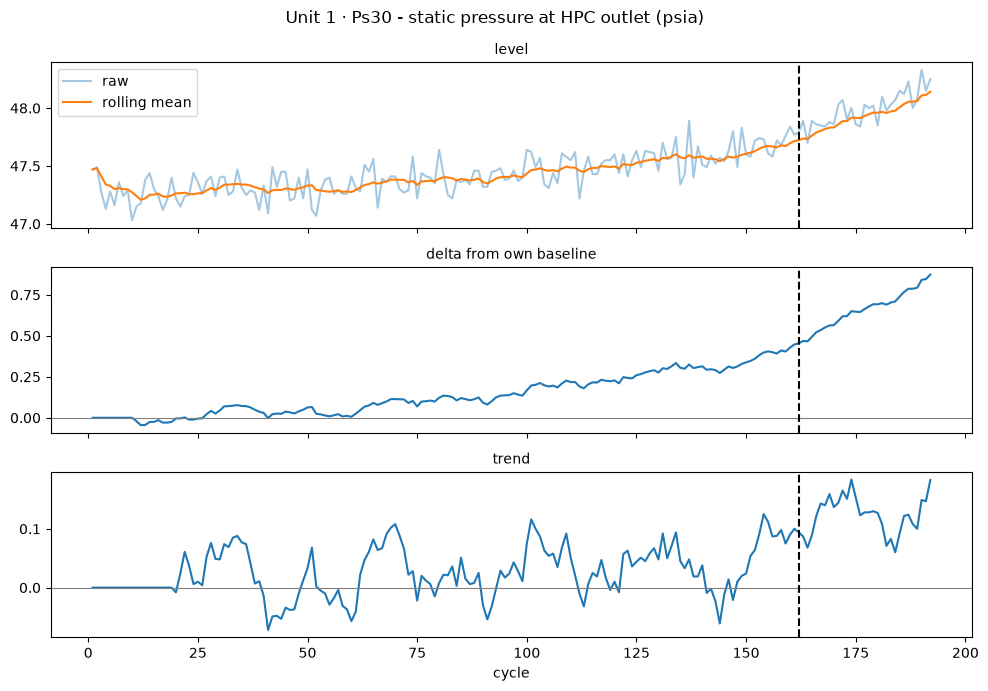

In [2]:
unit_id, sensor = 1, "sensor_11"
in_unit = train["unit"] == unit_id
unit, unit_features = train[in_unit], features[in_unit]
label_start = unit["cycle"].max() - HORIZON

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(unit["cycle"], unit[sensor], alpha=0.4, label="raw")
axes[0].plot(unit["cycle"], unit_features[f"{sensor}_mean{config.window}"], label="rolling mean")
axes[0].legend()
axes[1].plot(unit["cycle"], unit_features[f"{sensor}_delta_baseline"])
axes[1].axhline(0, color="grey", linewidth=0.8)
axes[2].plot(unit["cycle"], unit_features[f"{sensor}_trend{config.trend_lag}"])
axes[2].axhline(0, color="grey", linewidth=0.8)
for ax, title in zip(axes, ["level", "delta from own baseline", "trend"], strict=True):
    ax.axvline(label_start, color="black", linestyle="--")
    ax.set_title(title, fontsize=10)
axes[2].set_xlabel("cycle")
fig.suptitle(f"Unit {unit_id} · {SENSOR_DESCRIPTIONS[sensor]}")
fig.tight_layout()
plt.show()

## 2. Do the features carry more signal than the raw sensors?

Spearman correlation with RUL, sensor by sensor. Smoothing usually increases the correlation simply because it removes noise, not because it adds new information. The question for `delta_baseline` is whether removing each unit's offset helps beyond smoothing.

In [3]:
def spearman_with_rul(column):
    return column.corr(train["rul"], method="spearman")


correlations = pd.DataFrame(
    {
        sensor: {
            "raw": spearman_with_rul(train[sensor]),
            "rolling_mean": spearman_with_rul(features[f"{sensor}_mean{config.window}"]),
            "trend": spearman_with_rul(features[f"{sensor}_trend{config.trend_lag}"]),
            "delta_baseline": spearman_with_rul(features[f"{sensor}_delta_baseline"]),
        }
        for sensor in config.sensors
    }
).T
correlations["name"] = [SENSOR_DESCRIPTIONS[s].split(" - ")[0] for s in correlations.index]
correlations.round(3)

,raw,rolling_mean,trend,delta_baseline,name
sensor_2,-0.629,-0.742,-0.356,-0.799,T24
sensor_3,-0.606,-0.750,-0.319,-0.788,T30
sensor_4,-0.702,-0.753,-0.468,-0.852,T50
sensor_7,0.679,0.731,0.445,0.836,P30
sensor_8,-0.574,-0.600,-0.420,-0.724,Nf
sensor_9,-0.322,-0.327,-0.294,-0.374,Nc
sensor_11,-0.718,-0.749,-0.532,-0.865,Ps30
sensor_12,0.693,0.729,0.485,0.841,phi
sensor_13,-0.573,-0.599,-0.403,-0.743,NRf
sensor_14,-0.202,-0.204,-0.201,-0.214,NRc


## 3. Leakage experiment, repeated with features

In notebook 01, with raw sensors, a random row split and a split by unit gave the same PR-AUC. Rolling features make neighbouring rows share information (overlapping windows), so the risk should now be larger. Same diagnostic model, five folds each.

The features are computed once on the full training set. That is legitimate because each row only uses its own unit's past; what changes between the two experiments is only which rows end up in validation.

The model here is a fixed diagnostic (`n_estimators=100` to keep it fast); the model comparison is block 1.3. This cell takes a few minutes.

In [4]:
y = train[LABEL_COLUMN]
model = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=42)
unit_folds = unit_group_kfold(train, n_splits=5)

fold_summary = pd.DataFrame(
    [
        {"fold": i, "units": train["unit"].iloc[idx].nunique(), "positive_rate": y.iloc[idx].mean()}
        for i, (_, idx) in enumerate(unit_folds, start=1)
    ]
)
print("Validation folds (no stratification needed: every unit has HORIZON + 1 positive cycles)")
print(fold_summary.round(3).to_string(index=False))

splits = {
    "random rows (KFold, shuffled)": KFold(n_splits=5, shuffle=True, random_state=42),
    "whole units (GroupKFold)": unit_folds,
}
leakage = pd.DataFrame(
    {
        name: cross_val_score(model, features, y, cv=cv, scoring="average_precision")
        for name, cv in splits.items()
    }
).T
leakage.columns = [f"fold_{i}" for i in range(1, leakage.shape[1] + 1)]
leakage.assign(mean=leakage.mean(axis=1), std=leakage.std(axis=1)).round(3)

Validation folds (no stratification needed: every unit has HORIZON + 1 positive cycles)
 fold  units  positive_rate
    1     20           0.15
    2     20           0.15
    3     20           0.15
    4     20           0.15
    5     20           0.15


,fold_1,fold_2,fold_3,fold_4,fold_5,mean,std
"random rows (KFold, shuffled)",0.991,0.994,0.994,0.996,0.993,0.994,0.002
whole units (GroupKFold),0.959,0.981,0.974,0.978,0.969,0.972,0.008


## 4. Should the age of the unit (`cycle`) be a feature?

The age of a unit is known at prediction time, so using it is not leakage. The risk is different: in this fleet every unit fails between cycle 128 and 362, so the model could learn "old units fail" instead of reading their health, and that would not transfer to units with a different life.

Decision rule, fixed **before** looking at the result: `cycle` is added only if it improves grouped PR-AUC by more than one standard deviation across folds.

In [5]:
def grouped_pr_auc(feature_matrix):
    scores = cross_val_score(model, feature_matrix, y, cv=unit_folds, scoring="average_precision")
    return pd.Series({"mean": scores.mean(), "std": scores.std()})


with_cycle = build_features(train, FeatureConfig(include_cycle=True))
pd.DataFrame(
    {
        "without cycle": grouped_pr_auc(features),
        "with cycle": grouped_pr_auc(with_cycle),
    }
).T.round(4)

,mean,std
without cycle,0.9724,0.0076
with cycle,0.9812,0.0058


## 5. Findings (block 1.2)

- **Raw vs features:** `delta_baseline` has the strongest correlation with RUL for all 14 sensors (|ρ| up to 0.865 for sensor 11, vs 0.718 raw). Smoothing (raw → rolling mean) adds up to +0.14, mostly for noisy or quantised sensors (3, 17, 2, 20, 21); removing each unit's offset (rolling mean → `delta_baseline`) adds a further +0.03 to +0.14, most for the fan speeds 13 and 8 and for sensors 11, 12 and 7. Sensors 9 and 14 stay far below the rest (−0.37 / −0.21): removing an offset cannot fix trends that go in opposite directions across units. `trend` is the weakest on its own (|ρ| 0.20–0.53): it is noisy and near zero for most of a unit's life.
- **Warm-up artefact:** a first run showed a spike in `trend` around cycle 11, because early rolling means cover fewer than 10 cycles. Fixed: `trend` is 0 until both windows are complete (cycle ≥ 20), with a dedicated test. After the fix its correlation with RUL rose slightly for every sensor (sensor 11: −0.511 → −0.532).
- **Leakage with features:** random rows 0.994 ± 0.002 vs whole units 0.972 ± 0.008. With overlapping windows the gap appears, as anticipated in notebook 01: each validation row has near-identical neighbours in training. The random split hides most of the real errors (1 − PR-AUC of 0.006 vs 0.028) and is suspiciously stable. Grouped CV by unit is confirmed. Folds are balanced without stratification (positive rate 0.15 in every fold).
- **Cycle ablation:** 0.9724 ± 0.0076 without vs 0.9812 ± 0.0058 with `cycle`. The gain (+0.0088) exceeds both standard deviations, so `cycle` passes the pre-registered rule and is included (D-018). Before the warm-up fix the gain equalled one standard deviation and `cycle` had been excluded; the same rule was applied again to the corrected features. Risk accepted and recorded: the model may partly learn this fleet's lifetimes.
- **Open questions:**
  - How do validation scores (15% prevalence) translate to the test set (2.5%)? → block 1.3.
  - How much does the model rely on `cycle`, and how do the redundant pairs (8/13, 9/14) split attributions? → block 1.5.

## 6. Model comparison (block 1.3)

Every candidate is a complete Pipeline (raw sensor history → features → model) evaluated with the **same five unit folds** as section 3, so the comparison is fair and no row is ever scored by a model that saw its unit.

- **Candidates**, from simplest to most complex: logistic regression, random forest, gradient boosting (scikit-learn's histogram implementation) and XGBoost.
- **Inputs:** the selected feature set, the 42 sensor features plus `cycle` (included after section 4, D-018).
- **Reference:** a random forest on the current-cycle values of the same inputs (raw sensors and age). It answers the open question of block 1.2: do the engineered features help under the same protocol?
- **Hyperparameters:** fixed, reasonable defaults, not tuned. With 100 units, tuning on the same folds used to compare models would make the comparison optimistic (see D-020).
- **Primary metric: PR-AUC.** Accuracy is misleading with 15% positives: a model that never predicts failure is already 85% accurate. PR-AUC focuses on the positive class; its value for a random model equals the prevalence (0.15).

This cell trains 25 models and takes a few minutes.

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve

from industrial_ai.evaluation.metrics import (
    first_alarms,
    last_cycle_mask,
    select_threshold,
    threshold_metrics,
)
from industrial_ai.ml.data import load_rul
from industrial_ai.ml.labels import add_rul_test
from industrial_ai.ml.models import MODEL_NAMES, build_pipeline, model_inputs
from industrial_ai.ml.selection import cross_validate_by_unit, simplest_within_one_std

X = model_inputs(train)  # unit, cycle and sensors only: the labels never enter the model
print(f"Accuracy of a model that never predicts failure: {1 - y.mean():.3f}")

candidates = {"random_forest · raw sensors (reference)": build_pipeline("random_forest", "raw")}
candidates |= {name: build_pipeline(name) for name in MODEL_NAMES}

cv_results = {}
for label, pipeline in candidates.items():
    cv_results[label] = cross_validate_by_unit(pipeline, X, y, unit_folds)
    print(f"done: {label}")

comparison = pd.DataFrame({label: result.summary() for label, result in cv_results.items()}).T
comparison.round(3)

Accuracy of a model that never predicts failure: 0.850
done: random_forest · raw sensors (reference)
done: logistic_regression
done: random_forest
done: hist_gradient_boosting
done: xgboost


,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,fit_seconds
random_forest · raw sensors (reference),0.952,0.008,0.990,0.002,6.512
logistic_regression,0.991,0.001,0.998,0.000,0.955
random_forest,0.982,0.006,0.997,0.001,8.441
hist_gradient_boosting,0.992,0.004,0.998,0.001,4.798
xgboost,0.992,0.004,0.998,0.001,5.343


## 7. Model selection

Rule fixed **before** looking at the results: choose the **simplest candidate whose mean PR-AUC is within one standard deviation of the best** (the best candidate's own standard deviation across folds). A difference smaller than the fold-to-fold noise is not evidence for a more complex model. Complexity order: logistic regression < random forest < gradient boosting < XGBoost (fewer knobs and more transparent behaviour first). The raw-sensor reference is not a candidate.

The plot shows each model's PR-AUC per fold. If the lines move together, the hard part is *which units* are in the fold, not which model is used.

Selected model: logistic_regression


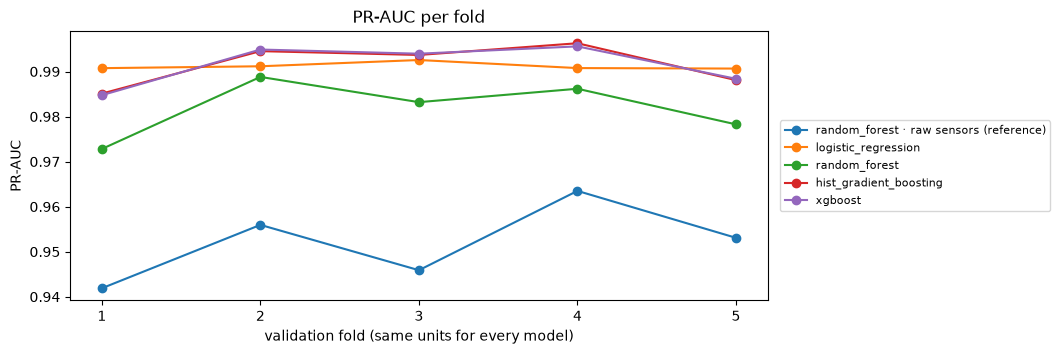

In [7]:
selected = simplest_within_one_std(comparison.loc[list(MODEL_NAMES)], MODEL_NAMES)
print(f"Selected model: {selected}")

fold_scores = pd.DataFrame({label: result.fold_pr_auc for label, result in cv_results.items()})
fig, ax = plt.subplots(figsize=(9, 3.5))
for label in fold_scores:
    ax.plot(range(1, len(unit_folds) + 1), fold_scores[label], marker="o", label=label)
ax.set(
    xlabel="validation fold (same units for every model)",
    ylabel="PR-AUC",
    title="PR-AUC per fold",
    xticks=range(1, len(unit_folds) + 1),
)
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.show()

## 8. Decision threshold

A model outputs a risk score; an **alarm** needs a threshold. 0.5 is an arbitrary default.

Rule fixed before looking at the results: the threshold with the **highest precision among those that reach recall ≥ 0.90**, chosen on the **out-of-fold** scores of the selected model (never on training predictions, never on the test set).

Why recall first: in this scenario, missing the warning window before a failure is assumed to cost more than an unnecessary inspection. That is a business assumption, not a universal truth: too many false alarms cause *alarm fatigue* and operators start ignoring them. With real maintenance costs, the threshold would minimise expected cost instead.

In [8]:
MIN_RECALL = 0.90
oof_scores = cv_results[selected].oof_scores
threshold = select_threshold(y, oof_scores, MIN_RECALL)

shown = ["threshold", "precision", "recall", "f1", "false_positive_rate", "false_negative_rate"]
shown += ["accuracy", "tp", "fp", "fn", "tn"]
pd.DataFrame(
    {
        "default threshold 0.5": threshold_metrics(y, oof_scores, 0.5),
        "selected threshold": threshold_metrics(y, oof_scores, threshold),
    }
).T[shown].round(3)

,threshold,precision,recall,f1,false_positive_rate,false_negative_rate,accuracy,tp,fp,fn,tn
default threshold 0.5,0.500,0.947,0.943,0.945,0.009,0.057,0.983,2923.0,165.0,177.0,17366.0
selected threshold,0.748,0.979,0.902,0.939,0.003,0.098,0.982,2797.0,59.0,303.0,17472.0


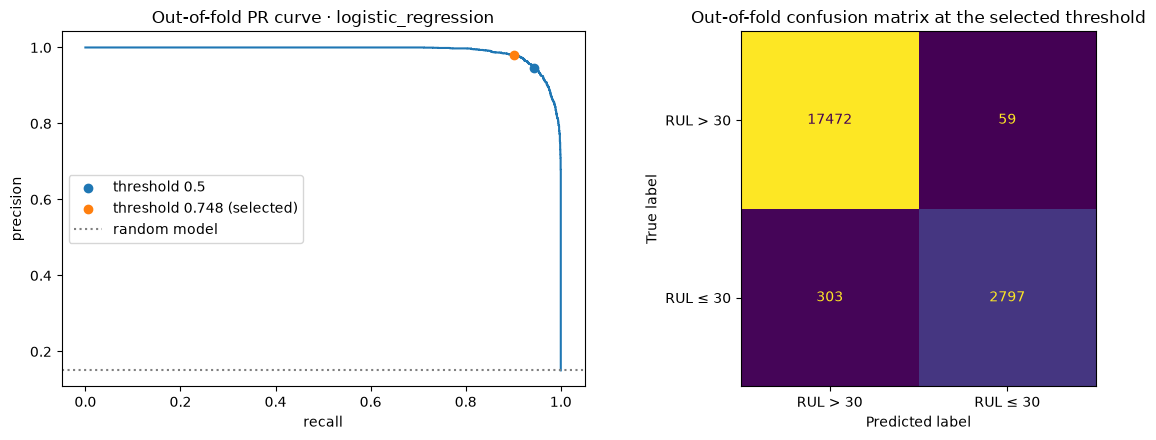

In [9]:
precision, recall, _ = precision_recall_curve(y, oof_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(recall, precision)
for name, value in [("0.5", 0.5), (f"{threshold:.3f} (selected)", threshold)]:
    point = threshold_metrics(y, oof_scores, value)
    axes[0].scatter(point["recall"], point["precision"], zorder=3, label=f"threshold {name}")
axes[0].axhline(y.mean(), color="grey", linestyle=":", label="random model")
axes[0].set(xlabel="recall", ylabel="precision", title=f"Out-of-fold PR curve · {selected}")
axes[0].legend()
ConfusionMatrixDisplay.from_predictions(
    y,
    (oof_scores >= threshold).astype(int),
    display_labels=[f"RUL > {HORIZON}", f"RUL ≤ {HORIZON}"],
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Out-of-fold confusion matrix at the selected threshold")
fig.tight_layout()
plt.show()

## 9. When does each unit raise its first alarm?

Row metrics count every cycle separately, but maintenance reacts to the **first alarm** of a unit. On out-of-fold scores every training unit fails, so we can measure how much warning each one would have given (its RUL at the first alarm):

- **missed:** no alarm before failure;
- **in window:** first alarm within the last `HORIZON` cycles;
- **early:** between `HORIZON` and `2 × HORIZON` cycles before failure, still useful warning;
- **premature:** more than `2 × HORIZON` cycles before failure, probably a false alarm.

Requiring the score to stay above the threshold for 3 consecutive cycles filters isolated spikes, at the cost of a few cycles of delay.

In [10]:
def alarm_outcomes(consecutive):
    rul = first_alarms(train, oof_scores, threshold, consecutive)["rul_at_first_alarm"]
    return pd.Series(
        {
            "missed (no alarm)": rul.isna().sum(),
            f"in window (RUL ≤ {HORIZON})": (rul <= HORIZON).sum(),
            f"early ({HORIZON} < RUL ≤ {2 * HORIZON})": rul.between(HORIZON + 1, 2 * HORIZON).sum(),
            f"premature (RUL > {2 * HORIZON})": (rul > 2 * HORIZON).sum(),
            "median RUL at first alarm": rul.median(),
            "least warning (min RUL at first alarm)": rul.min(),
            "unit with least warning": rul.idxmin(),
        }
    )


pd.DataFrame({f"{k} consecutive cycle(s)": alarm_outcomes(k) for k in (1, 3)})

,1 consecutive cycle(s),3 consecutive cycle(s)
missed (no alarm),0.0,0.0
in window (RUL ≤ 30),80.0,89.0
early (30 < RUL ≤ 60),20.0,11.0
premature (RUL > 60),0.0,0.0
median RUL at first alarm,28.0,26.0
least warning (min RUL at first alarm),18.0,16.0
unit with least warning,67.0,67.0


## 10. Final evaluation on the test set

The selected pipeline is refitted on all 100 training units and evaluated **once** on the test set, with the threshold chosen in section 8. Two views:

- **every cycle:** continuous monitoring of the fleet;
- **last cycle per unit:** the usual benchmark protocol, one prediction per unit.

Expected effect of the prevalence shift (15% → 2.5% positive cycles): recall should be comparable with cross-validation, while precision and PR-AUC will be lower, simply because there are fewer positives to find. The PR-AUC of a random model equals the prevalence of each view.

In [11]:
test = add_rul_test(load_trajectories("FD001", "test"), load_rul("FD001"))
test = add_failure_label(test, HORIZON)
final_model = build_pipeline(selected).fit(X, y)
test_scores = final_model.predict_proba(model_inputs(test))[:, 1]
last = last_cycle_mask(test).to_numpy()
y_test = test[LABEL_COLUMN].to_numpy()

shown = ["prevalence", "pr_auc", "roc_auc", "precision", "recall", "f1"]
shown += ["false_positive_rate", "tp", "fp", "fn", "tn"]
pd.DataFrame(
    {
        "cross-validation (out-of-fold)": threshold_metrics(y, oof_scores, threshold),
        "test · every cycle": threshold_metrics(y_test, test_scores, threshold),
        "test · last cycle per unit": threshold_metrics(y_test[last], test_scores[last], threshold),
    }
).T[shown].round(3)

,prevalence,pr_auc,roc_auc,precision,recall,f1,false_positive_rate,tp,fp,fn,tn
cross-validation (out-of-fold),0.150,0.991,0.998,0.979,0.902,0.939,0.003,2797.0,59.0,303.0,17472.0
test · every cycle,0.025,0.955,0.998,0.943,0.798,0.865,0.001,265.0,16.0,67.0,12748.0
test · last cycle per unit,0.250,0.997,0.999,1.000,0.920,0.958,0.000,23.0,0.0,2.0,75.0


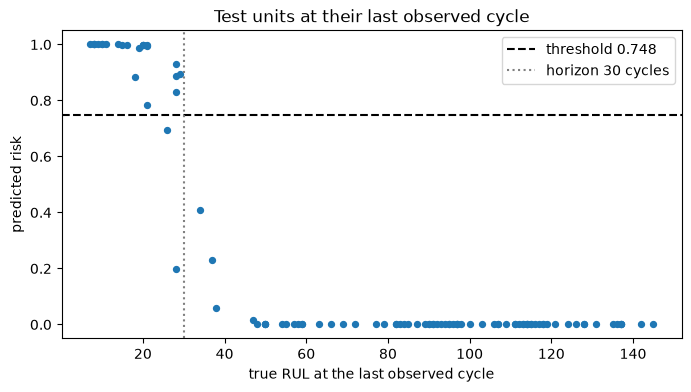

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(test["rul"].to_numpy()[last], test_scores[last], s=18)
ax.axhline(threshold, color="black", linestyle="--", label=f"threshold {threshold:.3f}")
ax.axvline(HORIZON, color="grey", linestyle=":", label=f"horizon {HORIZON} cycles")
ax.set(
    xlabel="true RUL at the last observed cycle",
    ylabel="predicted risk",
    title="Test units at their last observed cycle",
)
ax.legend()
plt.show()

### Recall by distance to failure

Recall drops from cross-validation to test. Hypothesis: test positives are concentrated near the horizon (truncated units contribute few positive cycles, mostly close to RUL 30), where the classes are hardest to separate. If it holds, recall within each band should be similar in cross-validation and test; only the mix of bands should differ.

In [13]:
def recall_by_rul_band(frame, scores):
    positives = (frame[LABEL_COLUMN] == 1).to_numpy()
    band = pd.cut(
        frame["rul"].to_numpy()[positives],
        bins=[-1, 10, 20, HORIZON],
        labels=["RUL 0–10", "RUL 11–20", f"RUL 21–{HORIZON}"],
    )
    detected = pd.Series(scores[positives] >= threshold)
    summary = detected.groupby(band, observed=False).agg(["size", "mean"])
    return summary.rename(columns={"size": "positive cycles", "mean": "recall"})


pd.concat(
    {
        "cross-validation": recall_by_rul_band(train, oof_scores),
        "test · every cycle": recall_by_rul_band(test, test_scores),
    },
    axis=1,
).round(3)

cross-validation        test · every cycle       
           positive cycles recall    positive cycles recall
RUL 0–10              1100  1.000                 17  1.000
RUL 11–20             1000  0.997                106  1.000
RUL 21–30             1000  0.700                209  0.679

## 11. Findings (block 1.3)

- **Accuracy trap:** a model that never predicts failure is 85.0% accurate; the selected model reaches 98.2% while still missing 10% of the positive cycles. Accuracy is not used to compare models.
- **Model comparison:** grouped PR-AUC with the selected features (42 sensor features + `cycle`): logistic regression 0.991 ± 0.001, random forest 0.982 ± 0.006, gradient boosting 0.992 ± 0.004, XGBoost 0.992 ± 0.004. Reference (random forest on current-cycle raw sensors and age): 0.952 ± 0.008. With the same random forest, the engineered features cut the remaining error from 0.048 to 0.018, and the reference is the lowest model in every fold.
- **Selection:** best mean 0.992 ± 0.004, so the band starts at 0.988; logistic regression (0.991) is inside it and is the simplest, most stable and fastest candidate, so it is selected (D-015). The gain came from the features, not from model complexity. XGBoost adds nothing over scikit-learn's gradient boosting.
- **Fold variability:** logistic regression is almost flat (0.991–0.993); the tree models vary more and the ranking among the top models changes between folds.
- **Effect of `cycle`:** logistic regression went from 0.973 ± 0.005 without `cycle` to 0.991 ± 0.001 with it, a larger gain than the random forest's. The model may lean on this fleet's lifetimes; to be checked in block 1.5.
- **Threshold:** 0.748 (out-of-fold precision 0.979, recall 0.902, false positive rate 0.3%). At 0.5 recall is already 0.943, so the rule raises the threshold: false alarms fall from 165 to 59 at the cost of 126 detected positive cycles.
- **Alarms per unit:** no unit is missed. 1 cycle: 80 in window, 20 early, 0 premature, median warning 28 cycles. 3 consecutive cycles: 89 / 11 / 0, median 26. Least warning: unit 67, 18 cycles (16 with 3 consecutive cycles).
- **Test set:** every cycle: PR-AUC 0.955 (random model: 0.025), precision 0.943, recall 0.798, false positive rate 0.1%. Last cycle per unit: PR-AUC 0.997, precision 1.000, recall 0.920 (23 of 25), no false positives. Precision holds despite the prevalence shift because the false positive rate also falls: most test cycles are far from failure.
- **Recall drop explained:** recall per RUL band is practically the same in cross-validation and test (1.000 / 0.997 / 0.700 vs 1.000 / 1.000 / 0.679), but the hard band (RUL 21–30) holds 63% of test positives vs 32% in cross-validation. With the cross-validation recall per band, test recall would be 0.810: the mix explains almost all of the drop from 0.902.
- **Where the errors are:** no false positives at the last cycle (units at RUL 34–38 score 0.06–0.41; beyond RUL 40 all score ≈ 0). One near miss (RUL ≈ 26, score 0.69) and one confident miss (RUL ≈ 28, score 0.20), the only clear error.
- **Open questions:**
  - How much does the model rely on `cycle`? → age-only baseline and attributions (block 1.5).
  - Why is the confident miss missed? → local explanation of that unit (block 1.5).
  - Are the probabilities calibrated, given the prevalence shift? → block 1.5.
  - Does an unsupervised anomaly detector give earlier or complementary warnings? → block 1.4.

## 12. Anomaly detection (block 1.4): idea and assumptions

The classifier of sections 6–11 needs failure labels. A real plant rarely has many recorded failures, and a new fault mode would not be among them. An anomaly detector answers a different question: **is this unit behaving differently from healthy operation?** It never sees a failure label; labels are used here only to evaluate it.

- **Healthy reference:** cycles 20–60 of each training unit. From cycle 20 the features are complete (baseline and trend windows filled); cycle 60 is still at least 68 cycles before the shortest observed failure (128). Assumption: degradation is negligible that early (notebook 01: noise dominates until the last 50–100 cycles).
- **Features:** deviation features only, `delta_baseline` and `trend` of the 14 sensors (28). Not the levels: units start at different levels, so a healthy region of levels is wide. Not `cycle`: every old cycle would look anomalous, because the reference only contains young units.
- **Two methods**, same features, window and threshold rule:
  - **max |z-score|** (baseline): the largest deviation of any feature from its healthy mean, in standard deviations. This is the logic of a control chart.
  - **Isolation Forest:** isolates points that are easy to separate from the healthy cloud with random splits.
- **Label-free threshold:** the score exceeded by 1% of the healthy reference cycles (the false-alarm budget). An alarm needs **3 consecutive cycles** above the threshold.
- **Selection rule**, fixed before the results (D-021): fewer missed units wins; with the same number of missed units, Isolation Forest is chosen only if its median warning is at least 5 cycles longer and its healthy false-alarm rate is not higher; otherwise the simpler max |z-score|.

In [14]:
import numpy as np
from sklearn.base import clone

from industrial_ai.evaluation.metrics import summarize_first_alarms
from industrial_ai.ml.anomaly import AnomalyDetector, out_of_fold_margins

CONSECUTIVE = 3
detectors = {
    method: AnomalyDetector(method=method) for method in ("max_zscore", "isolation_forest")
}
healthy = detectors["max_zscore"].in_healthy_window(train).to_numpy()
far_from_failure = (train["rul"] > 2 * HORIZON).to_numpy()

first_cycle, last_cycle = detectors["max_zscore"].healthy_window()
print(f"Healthy reference: cycles {first_cycle}–{last_cycle}")
print(f"Reference rows: {healthy.sum():,} of {len(train):,}")

Healthy reference: cycles 20–60
Reference rows: 4,100 of 20,631


## 13. Out-of-fold evaluation

Same five unit folds as before: each detector is fitted on the healthy cycles of 80 units and scores the 20 held-out units. Each fold has its own threshold, so results are expressed as a **margin** (score − threshold; alarm when ≥ 0).

- **False alarms on healthy cycles** of held-out units: is the 1% budget respected on units the detector has never seen?
- **False alarms far from failure** (RUL > 60) and **units alarmed while healthy** (3 consecutive cycles inside the reference window).
- **Metrics against the failure label** (RUL ≤ 30): the detector was not trained for that label, so they show how much of the failure window it catches, not what it is optimised for.

In [15]:
margins = {
    method: out_of_fold_margins(detector, X, unit_folds) for method, detector in detectors.items()
}


def detector_report(margin):
    alarms = margin >= 0
    while_healthy = first_alarms(train[healthy], margin[healthy], 0.0, CONSECUTIVE)
    against_label = threshold_metrics(y, margin, 0.0)
    return pd.Series(
        {
            "false alarms, healthy cycles": alarms[healthy].mean(),
            f"false alarms, RUL > {2 * HORIZON}": alarms[far_from_failure].mean(),
            "units alarmed while healthy": while_healthy["first_alarm_cycle"].notna().sum(),
            f"recall on RUL ≤ {HORIZON}": against_label["recall"],
            "precision vs failure label": against_label["precision"],
            "PR-AUC vs failure label": against_label["pr_auc"],
        }
    )


reports = pd.DataFrame({method: detector_report(margin) for method, margin in margins.items()}).T
reports.round(3)

,"false alarms, healthy cycles","false alarms, RUL > 60",units alarmed while healthy,recall on RUL ≤ 30,precision vs failure label,PR-AUC vs failure label
max_zscore,0.014,0.352,7.0,1.0,0.276,0.759
isolation_forest,0.011,0.348,5.0,1.0,0.278,0.850


## 14. Lead time: when does each unit raise its first alarm?

What a detector is for is **warning time**. For each training unit (out-of-fold), the RUL at its first alarm (3 consecutive cycles), next to the classifier of section 8 with the same alarm rule.

An alarm more than 2 × `HORIZON` cycles before failure is "premature": for the classifier it is probably false; for a detector it may also be the onset of degradation. The healthy false-alarm rate of section 13 helps tell them apart.

In [16]:
first_alarm_rul = {
    method: first_alarms(train, margin, 0.0, CONSECUTIVE)["rul_at_first_alarm"]
    for method, margin in margins.items()
}
first_alarm_rul["classifier"] = first_alarms(train, oof_scores, threshold, CONSECUTIVE)[
    "rul_at_first_alarm"
]
lead_times = pd.DataFrame(
    {name: summarize_first_alarms(rul, HORIZON) for name, rul in first_alarm_rul.items()}
).T
lead_times

,units,missed (no alarm),in window (RUL ≤ 30),early (30 < RUL ≤ 60),premature (RUL > 60),median RUL at first alarm,least warning (min RUL at first alarm)
max_zscore,100.0,0.0,0.0,0.0,100.0,109.0,62.0
isolation_forest,100.0,0.0,0.0,0.0,100.0,109.0,62.0
classifier,100.0,0.0,89.0,11.0,0.0,26.0,16.0


Selected detector: max_zscore


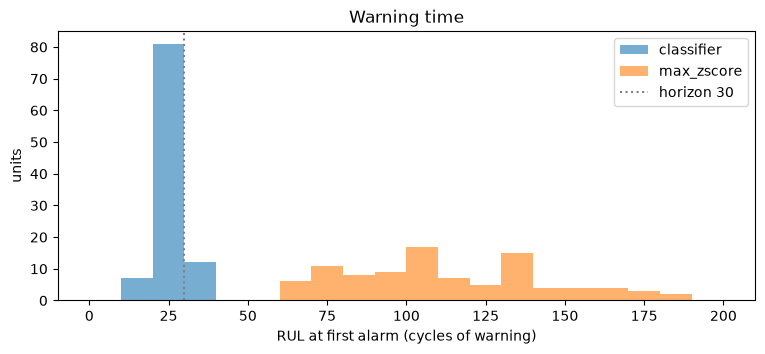

In [17]:
z_score, forest = lead_times.loc["max_zscore"], lead_times.loc["isolation_forest"]
missed, median = "missed (no alarm)", "median RUL at first alarm"
healthy_alarms = "false alarms, healthy cycles"

isolation_forest_wins = forest[missed] < z_score[missed] or (
    forest[missed] == z_score[missed]
    and forest[median] >= z_score[median] + 5
    and reports.loc["isolation_forest", healthy_alarms] <= reports.loc["max_zscore", healthy_alarms]
)
selected_detector = "isolation_forest" if isolation_forest_wins else "max_zscore"
print(f"Selected detector: {selected_detector}")

fig, ax = plt.subplots(figsize=(9, 3.5))
bins = range(0, 201, 10)
for name in ("classifier", selected_detector):
    ax.hist(first_alarm_rul[name].dropna(), bins=bins, alpha=0.6, label=name)
ax.axvline(HORIZON, color="grey", linestyle=":", label=f"horizon {HORIZON}")
ax.set(xlabel="RUL at first alarm (cycles of warning)", ylabel="units", title="Warning time")
ax.legend()
plt.show()

## 15. What the detector sees

**Trajectories:** the out-of-fold margin of ten held-out units, aligned by RUL. The vertical axis is linear around zero and logarithmic for large values, so both the threshold crossing and large deviations stay visible.

**Explanation:** the detector is refitted on the healthy cycles of all 100 training units (the version used on the test set), and for the test unit with the highest margin at its last observed cycle we list the features that deviate most from the healthy reference. This says *how* the unit differs from healthy operation, not *why*: a deviation is a symptom, not a diagnosed cause.

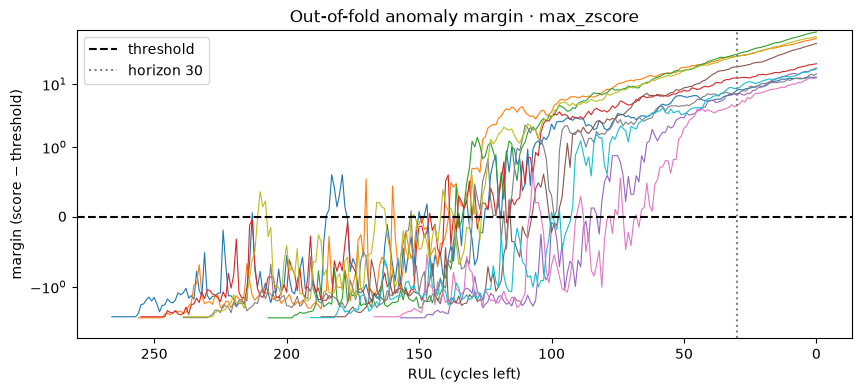

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
for unit in train["unit"].drop_duplicates().sample(10, random_state=42):
    in_unit = (train["unit"] == unit).to_numpy()
    ax.plot(train["rul"].to_numpy()[in_unit], margins[selected_detector][in_unit], linewidth=0.8)
ax.axhline(0, color="black", linestyle="--", label="threshold")
ax.axvline(HORIZON, color="grey", linestyle=":", label=f"horizon {HORIZON}")
ax.set_yscale("symlog", linthresh=1)
ax.invert_xaxis()
ax.set(
    xlabel="RUL (cycles left)",
    ylabel="margin (score − threshold)",
    title=f"Out-of-fold anomaly margin · {selected_detector}",
)
ax.legend()
plt.show()

In [19]:
final_detector = clone(detectors[selected_detector]).fit(X)
test_inputs = model_inputs(test)
test_margin = final_detector.margin(test_inputs)

last_rows = test.index[last]
row = last_rows[np.argmax(test_margin[last])]
case = test.loc[row]
print(
    f"Unit {case['unit']:.0f} at cycle {case['cycle']:.0f} (true RUL {case['rul']:.0f}): "
    f"margin {test_margin[test.index.get_loc(row)]:.2f}"
)

deviations = final_detector.top_deviations(test_inputs, n=5)
deviations = deviations[deviations["row"] == row].drop(columns="row")
deviations["sensor"] = deviations["feature"].map(
    lambda name: SENSOR_DESCRIPTIONS["_".join(name.split("_")[:2])]
)
deviations.round(2)

Unit 100 at cycle 198 (true RUL 20): margin 57.82


,rank,feature,zscore,sensor
65475,1,sensor_14_delta_baseline,61.33,NRc - corrected core speed (rpm)
65476,2,sensor_9_delta_baseline,50.36,Nc - physical core speed (rpm)
65477,3,sensor_4_delta_baseline,12.13,T50 - total temperature at LPT outlet (°R)
65478,4,sensor_14_trend10,11.50,NRc - corrected core speed (rpm)
65479,5,sensor_9_trend10,9.58,Nc - physical core speed (rpm)


## 16. Ablation: sensor levels instead of deviations

Question fixed in advance: what if the detector used the levels (`mean10`) instead of the deviation features? The expectation is worse detection, because the healthy region of levels includes the unit-to-unit offsets seen in notebook 01, so degradation must exceed the fleet's spread before it looks abnormal.

In [20]:
levels_margin = out_of_fold_margins(
    AnomalyDetector(method=selected_detector, feature_kinds=("mean",)), X, unit_folds
)
levels_rul = first_alarms(train, levels_margin, 0.0, CONSECUTIVE)["rul_at_first_alarm"]
pd.DataFrame(
    {
        "deviations (selected)": pd.concat(
            [
                detector_report(margins[selected_detector]),
                pd.Series(summarize_first_alarms(first_alarm_rul[selected_detector], HORIZON)),
            ]
        ),
        "levels": pd.concat(
            [detector_report(levels_margin), pd.Series(summarize_first_alarms(levels_rul, HORIZON))]
        ),
    }
).round(3)

,deviations (selected),levels
"false alarms, healthy cycles",0.014,0.018
"false alarms, RUL > 60",0.352,0.110
units alarmed while healthy,7.000,8.000
recall on RUL ≤ 30,1.000,0.993
precision vs failure label,0.276,0.449
PR-AUC vs failure label,0.759,0.821
units,100.000,100.000
missed (no alarm),0.000,0.000
in window (RUL ≤ 30),0.000,11.000
early (30 < RUL ≤ 60),0.000,36.000


## 17. Test set

The detector fitted on all training units is evaluated once on the test set, next to the classifier. Test units stop before failure, so warning time cannot be measured here; instead: false alarms far from failure, recall on the failure window and the last-cycle view. Alarms here are single cycles (no consecutive rule), as in section 10.

In [21]:
far_from_failure_test = (test["rul"] > 2 * HORIZON).to_numpy()
print(
    f"Detector false-alarm rate on test cycles with RUL > {2 * HORIZON}: "
    f"{(test_margin >= 0)[far_from_failure_test].mean():.3f}"
)

shown = ["prevalence", "pr_auc", "precision", "recall", "false_positive_rate"]
shown += ["tp", "fp", "fn", "tn"]
pd.DataFrame(
    {
        "detector · every cycle": threshold_metrics(y_test, test_margin, 0.0),
        "classifier · every cycle": threshold_metrics(y_test, test_scores, threshold),
        "detector · last cycle per unit": threshold_metrics(y_test[last], test_margin[last], 0.0),
        "classifier · last cycle per unit": threshold_metrics(
            y_test[last], test_scores[last], threshold
        ),
    }
).T[shown].round(3)

Detector false-alarm rate on test cycles with RUL > 60: 0.232


,prevalence,pr_auc,precision,recall,false_positive_rate,tp,fp,fn,tn
detector · every cycle,0.025,0.434,0.083,1.000,0.287,332.0,3657.0,0.0,9107.0
classifier · every cycle,0.025,0.955,0.943,0.798,0.001,265.0,16.0,67.0,12748.0
detector · last cycle per unit,0.250,0.821,0.347,1.000,0.627,25.0,47.0,0.0,28.0
classifier · last cycle per unit,0.250,0.997,1.000,0.920,0.000,23.0,0.0,2.0,75.0


## 18. Findings (block 1.4)

- **Healthy false alarms:** budget (1%) vs out-of-fold rate on unseen units, and units alarmed while healthy:
- **Detection:** missed units and warning time of each detector, compared with the classifier:
- **Selection:** result of the rule and why:
- **Trajectories:** what the margins show as failure approaches:
- **Explanation:** most deviating features of the most anomalous test unit:
- **Levels vs deviations:**
- **Test set:** detector vs classifier:
- **Open questions:**